In [13]:
import numpy as np

CODON_TABLE = {
    "TTT": "F", "TTC": "F", "TTA": "L", "TTG": "L",
    "CTT": "L", "CTC": "L", "CTA": "L", "CTG": "L",
    "ATT": "I", "ATC": "I", "ATA": "I", "ATG": "M",
    "GTT": "V", "GTC": "V", "GTA": "V", "GTG": "V",
    "TCT": "S", "TCC": "S", "TCA": "S", "TCG": "S",
    "CCT": "P", "CCC": "P", "CCA": "P", "CCG": "P",
    "ACT": "T", "ACC": "T", "ACA": "T", "ACG": "T",
    "GCT": "A", "GCC": "A", "GCA": "A", "GCG": "A",
    "TAT": "Y", "TAC": "Y", "TAA": "*", "TAG": "*",
    "CAT": "H", "CAC": "H", "CAA": "Q", "CAG": "Q",
    "AAT": "N", "AAC": "N", "AAA": "K", "AAG": "K",
    "GAT": "D", "GAC": "D", "GAA": "E", "GAG": "E",
    "TGT": "C", "TGC": "C", "TGA": "*", "TGG": "W",
    "CGT": "R", "CGC": "R", "CGA": "R", "CGG": "R",
    "AGT": "S", "AGC": "S", "AGA": "R", "AGG": "R",
    "GGT": "G", "GGC": "G", "GGA": "G", "GGG": "G",
}

PHYSICOCHEMICAL_GROUPS = {
    "A": "nonpolar", "V": "nonpolar", "I": "nonpolar", "L": "nonpolar",
    "M": "nonpolar", "F": "nonpolar", "W": "nonpolar", "P": "nonpolar",
    "G": "polar",    "S": "polar",    "T": "polar",    "C": "polar",
    "Y": "polar",    "N": "polar",    "Q": "polar",
    "D": "acidic",   "E": "acidic",
    "K": "basic",    "R": "basic",    "H": "basic",
}

HBOND_GROUPS = {
    "A": 2, "T": 2,
    "G": 3, "C": 3,
}

def translate_motif(motif):
    amino_acids = []
    for i in range(0, len(motif), 3):
        codon = motif[i:i+3]
        amino_acids.append(CODON_TABLE.get(codon, "?"))
    return amino_acids

def compute_fitness_nucleotide(chromosome, sequences, motif_length):
    motifs = [seq[pos: pos + motif_length] for seq, pos in zip(sequences, chromosome)]
    PFM = np.zeros((4, motif_length))
    for motif in motifs:
        for col, char in enumerate(motif):
            if char == "A": PFM[0, col] += 1
            elif char == "T": PFM[1, col] += 1
            elif char == "C": PFM[2, col] += 1
            elif char == "G": PFM[3, col] += 1
    return sum(max(PFM[:, col]) for col in range(motif_length))

def compute_fitness_aminoacid(chromosome, sequences, motif_length):
    motifs = [seq[pos: pos + motif_length] for seq, pos in zip(sequences, chromosome)]
    translated = [translate_motif(motif) for motif in motifs]
    num_codons = motif_length // 3
    score = 0
    for col in range(num_codons):
        col_aas = [t[col] for t in translated]
        counts = {}
        for aa in col_aas:
            counts[aa] = counts.get(aa, 0) + 1
        score += max(counts.values())
    return score

def compute_fitness_physicochemical(chromosome, sequences, motif_length):
    motifs = [seq[pos: pos + motif_length] for seq, pos in zip(sequences, chromosome)]
    translated = [translate_motif(motif) for motif in motifs]
    num_codons = motif_length // 3
    score = 0
    for col in range(num_codons):
        col_aas = [t[col] for t in translated]
        counts = {}
        for aa in col_aas:
            group = PHYSICOCHEMICAL_GROUPS.get(aa, "unknown")
            counts[group] = counts.get(group, 0) + 1
        score += max(counts.values())
    return score

def compute_fitness_hbond(chromosome, sequences, motif_length):
    motifs = [seq[pos: pos + motif_length] for seq, pos in zip(sequences, chromosome)]
    score = 0
    for col in range(motif_length):
        counts = {}
        for motif in motifs:
            group = HBOND_GROUPS.get(motif[col], -1)
            counts[group] = counts.get(group, 0) + 1
        score += max(counts.values())
    return score

def compute_fitness(chromosome, sequences, motif_length):
    if FITNESS_MODE == "nucleotide":
        return compute_fitness_nucleotide(chromosome, sequences, motif_length)
    elif FITNESS_MODE == "aminoacid":
        return compute_fitness_aminoacid(chromosome, sequences, motif_length)
    elif FITNESS_MODE == "physicochemical":
        return compute_fitness_physicochemical(chromosome, sequences, motif_length)
    elif FITNESS_MODE == "hbond":
        return compute_fitness_hbond(chromosome, sequences, motif_length)
    else:
        raise ValueError(f"Unknown FITNESS_MODE: '{FITNESS_MODE}'. Choose from: 'nucleotide', 'aminoacid', 'physicochemical', 'hbond'.")

In [2]:
import random
random.seed(42)
np.random.seed(42)

def initialize_population(pop_size, sequences, motif_length):
    population = [[random.randint(0, len(seq) - motif_length) for seq in sequences] for _ in range(pop_size)]
    return population

In [3]:
def tournament_select(population, fitnesses, tournament_size):
    rand_selected_pop = random.sample(range(len(population)), tournament_size)
    winner_index = max(rand_selected_pop, key=lambda i: fitnesses[i])
    return population[winner_index]

In [4]:
def mutate(chromosome, sequences, motif_length, mutation_rate=0.3):
    if random.random() < mutation_rate:
        i = random.randint(0, len(chromosome) - 1)
        chromosome = chromosome[:]
        chromosome[i] = random.randint(0, len(sequences[i]) - motif_length)
    return chromosome

In [5]:
def crossover(parent_a, parent_b, crossover_rate=0.3):
    n = len(parent_a)
    segment_length = max(1, int(crossover_rate * n))
    start = random.randint(0, n - segment_length)
    end = start + segment_length

    child_a = parent_a[:start] + parent_b[start:end] + parent_a[end:]
    child_b = parent_b[:start] + parent_a[start:end] + parent_b[end:]

    return child_a, child_b

In [6]:
def write_to_txt (string, filename):
    with open(filename, "a") as f:
        f.write(string + "\n")
def read_txt_and_return_lines(filename):
    with open(filename, "r") as f:
        lines = [line.strip() for line in f]
    return lines

In [14]:
import matplotlib.pyplot as plt

def run_ga_with_history(population, sequences, motif_length, num_generations, tournament_size, mutation_rate, elite_count):
    best_chromosome = None
    best_fitness = 0
    
    history = {
        "best": [],
        "avg": [],
        "worst": []
    }
    
    for gen in range(num_generations):
        fitnesses = [compute_fitness(individual, sequences, motif_length) for individual in population]
        
        # Track stats before selection
        history["best"].append(max(fitnesses))
        history["avg"].append(sum(fitnesses) / len(fitnesses))
        history["worst"].append(min(fitnesses))
        
        elite_indices = sorted(range(len(fitnesses)), key=lambda i: fitnesses[i], reverse=True)[:elite_count]
        elites = [population[i] for i in elite_indices]
        new_population = elites[:]
        
        while len(new_population) < len(population):
            parent_a = tournament_select(population, fitnesses, tournament_size)
            parent_b = tournament_select(population, fitnesses, tournament_size)
            child_a, child_b = crossover(parent_a, parent_b)
            mutated_a = mutate(child_a, sequences, motif_length, mutation_rate)
            mutated_b = mutate(child_b, sequences, motif_length, mutation_rate)
            new_population.append(mutated_a)
            if len(new_population) < len(population):
                new_population.append(mutated_b)

        population = new_population
        fitnesses = [compute_fitness(individual, sequences, motif_length) for individual in population]
        
        gen_best_index = fitnesses.index(max(fitnesses))
        if fitnesses[gen_best_index] > best_fitness:
            best_fitness = fitnesses[gen_best_index]
            best_chromosome = population[gen_best_index]
    
    return best_chromosome, best_fitness, history


def plot_convergence(history, motif_length, num_generations, sequences, fitness_mode, save_path=None):
    if fitness_mode in ("nucleotide", "hbond"):
        max_possible = motif_length * len(sequences)
    else:  # aminoacid or physicochemical
        max_possible = (motif_length // 3) * len(sequences)

    generations = list(range(1, num_generations + 1))

    plt.figure(figsize=(10, 5))
    plt.plot(generations, history["best"],  label="Best Fitness",  color="royalblue",  linewidth=2)

    plt.axhline(y=max_possible, color="green", linestyle="--", linewidth=1, label=f"Max Possible ({max_possible})")

    plt.xlabel("Generation")
    plt.ylabel("Fitness Score")
    plt.title(f"GA Convergence — Motif Length {motif_length} ({fitness_mode})")
    plt.legend()
    plt.tight_layout()
    plt.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved to {save_path}")

    plt.show()

Mode: nucleotide
Best fitness: 146.0/180
Best normalized fitness: 0.8111111111111111
Best chromosome: [6871, 12030, 27216, 17712, 26946, 17716, 8424, 13910, 7669, 6014, 4315, 11390, 19183, 26287, 6748, 22853, 4745, 17013, 13926, 2377]
CAACCGCCC
CACCCGCCC
CTACCACAC
CAACCCACC
CATCCATCC
CAGCCACCC
CAACAACTC
TAACCACGC
CAAGCAACC
CAACCACGC
CAACCACAA
CGACCACCT
CAACTGCCC
CAACGATCC
CGTCCACCC
CAACAACCC
CAGCTACCC
CAACCGCCC
CAACCCTCC
CAATCACCC
Saved to convergence.png


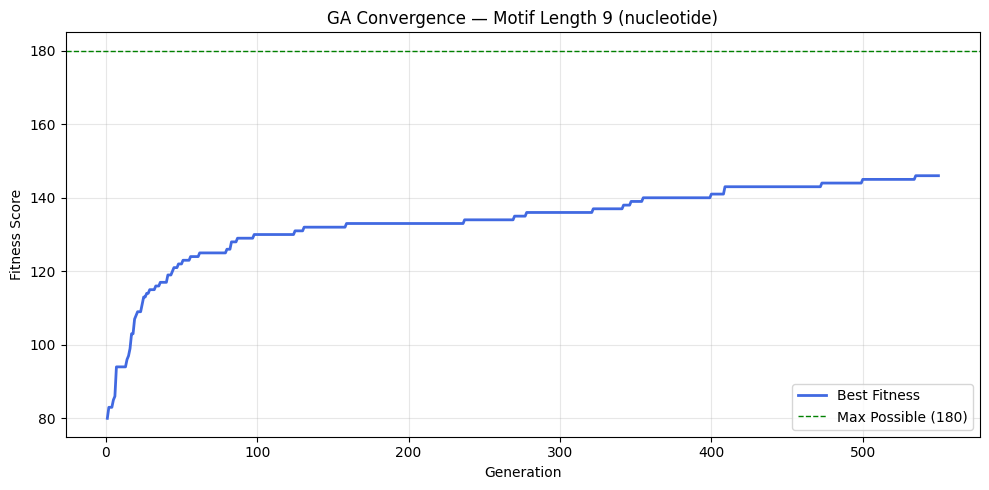

In [31]:
sequences = read_txt_and_return_lines("full_char_seq.txt")

POP_SIZE = 300
NUM_GENERATIONS = 550
TOURNAMENT_SIZE = 3
MUTATION_RATE = 0.3
ELITE_COUNT = 2
MOTIF_LENGTH = 9
FITNESS_MODE = "nucleotide" # "nucleotide" | "aminoacid" | "physicochemical" | "hbond"

if MOTIF_LENGTH % 3 != 0:
    raise ValueError(f"MOTIF_LENGTH must be divisible by 3. Got {MOTIF_LENGTH}.")

population = initialize_population(POP_SIZE, sequences, MOTIF_LENGTH)
best_chromosome, best_fitness, history = run_ga_with_history(
    population, sequences, MOTIF_LENGTH, NUM_GENERATIONS,
    TOURNAMENT_SIZE, MUTATION_RATE, ELITE_COUNT
)

if FITNESS_MODE in ("nucleotide", "hbond"):
    max_possible = MOTIF_LENGTH * len(sequences)
else:
    max_possible = (MOTIF_LENGTH // 3) * len(sequences)

print(f"Mode: {FITNESS_MODE}")
print(f"Best fitness: {best_fitness}/{max_possible}")
print(f"Best normalized fitness: {best_fitness/max_possible}")
print(f"Best chromosome: {best_chromosome}")

best_motifs = [seq[pos: pos + MOTIF_LENGTH] for seq, pos in zip(sequences, best_chromosome)]
for motif in best_motifs:
    print(motif)

plot_convergence(history, MOTIF_LENGTH, NUM_GENERATIONS, sequences, FITNESS_MODE, save_path="convergence.png")